# 策略梯度算法--log

本书之前介绍的 Q-learning、DQN 及 DQN 改进算法都是**基于价值（value-based）的方法**，
其中 ：
- Q-learning 是处理有限状态的算法，
- 而 DQN 可以用来解决连续状态的问题。

在强化学习中，除了基于值函数的方法，还有一支非常经典的方法，那就是**基于策略（policy-based）的方法**。

对比两者:
- **基于值函数**的方法主要是学习值函数，然后根据值函数导出一个策略，学习过程中并不存在一个显式的策略；
- **基于策略**的方法则是直接显式地**学习一个目标策略**。
  - 策略梯度是基于策略的方法的基础，本章从策略梯度算法说起。

## 策略梯度

基于策略的方法首先需要将策略参数化。
- 假设目标策略$π_θ$是一个随机性策略，并且处处可微，其中θ是对应的参数。
- 我们可以用一个线性模型或者神经网络模型来**为这样一个策略函数建模**：
     - 输入：某个状态，
     - 然后输出：一个**动作的概率分布**。

#### 我们的目标是：要寻找一个最优策略并最大化这个策略在环境中的期望回报。

我们将策略学习的目标函数定义为
$J(θ) = E_{s_0}[V^{π_θ}{(s_0)}]$

- $s_0$表示初始状态。

<font color="red">**现在有了目标函数，我们将目标函数对策略θ求导，得到导数后，就可以用梯度上升方法来最大化这个目标函数，从而得到最优策略。**<font>



In [1]:
from IPython.display import Image


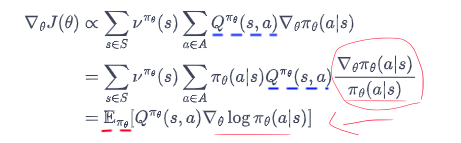

In [3]:
Image(filename="./image/target.png",width=600)

我第 3 章讲解过策略π下的状态访问分布，在此用$V^π$表示。然后我们对目标函数求梯度，可以得到如上图中的式子，更详细的推导过程将在 9.6 节给出

### 这个梯度可以用来更新策略。
- 需要注意的是，因为上式中期望E的下标是$π_θ$，所以**策略梯度算法为在线策略（on-policy）算法**，
- 即必须使用当前策略$π_θ$采样得到的数据来计算梯度。

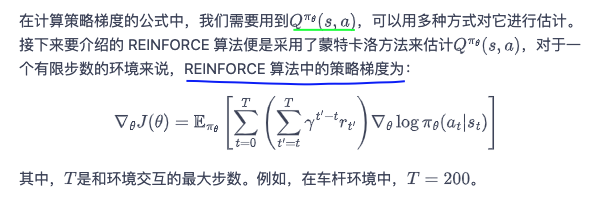

In [4]:
Image(filename="./image/reinforce.png",width=600)

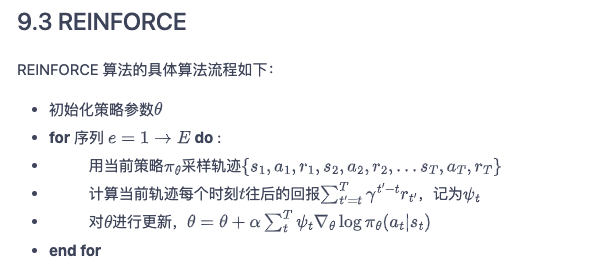

In [6]:
Image(filename="./image/rein_step.png",width=500)

## REINFORCE 代码实践

In [20]:

import gym
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import rl_utils

- 首先定义策略网络PolicyNet，
  - 其**输入**是:**某个状态**
  - **输出**:则是**该状态下的动作概率分布**
  - 这里采用在离散动作空间上的softmax()函数来实现一个可学习的多项分布（multinomial distribution）。

In [7]:
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    # 其输入是某个状态，输出则是该状态下的动作概率分布
    def forward(self, x):
        x = F.relu(self.fc1(x))
        # 这里采用在离散动作空间上的softmax()函数来实现一个可学习的多项分布
        return F.softmax(self.fc2(x), dim=1)

### 再定义我们的 REINFORCE 算法。

- 在函数take_action()函数中，我们通过动作概率分布对离散的动作进行采样。

- 在更新过程中，我们按照算法将损失函数写为策略回报的负数,对θ求导后就可以通过梯度下降来更新策略

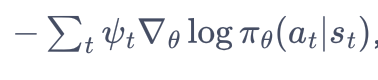

In [8]:
Image(filename='./image/policy_loss.png',width=400)

In [14]:
'''定义REINFORCE算法'''
class REINFORCE:
    def __init__(self,state_dim,hidden_dim,action_dim,learning_rate,gamma,device):
        
        self.policy_net = PolicyNet(state_dim,hidden_dim,action_dim).to(device)
        
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(),lr=learning_rate)
        self.gamma = gamma
        self.device = device
        
    def take_action(self,state):# 根据动作概率分布随机采样
        state = torch.tensor([state],dtype=torch.float).to(self.device)
        # 策略网络的输出是：在该状态下的概率分布
        probs = self.policy_net(state)
        # 定义分类分布
        action_dist = torch.distributions.Categorical(probs)
        # 根据分布采样动作
        action = action_dist.sample()
        return action.item()
    
    def update(self,transition_dict):
        reward_list = transition_dict['rewards']
        state_list = transition_dict['states']
        action_list = transition_dict['action']
        
        G = 0
        self.optimizer.zero_grad()
        for i in reversed(range(len(reward_list))): # 从后向前计算
            reward = reward_list[i]
            state = torch.tensor([state_list[i]],dtype=torch.float).to(self.device)
            action = torch.tensor([action_list[i]]).view(-1,1).to(self.device)
            
            log_prob = torch.log(self.policy_net(state).gather(1,action))
            G = reward + self.gamma * G
            # 每一步的损失函数
            loss = -log_prob * G 
            loss.backward() 
        
        # 更新    
        self.optimizer.step()
        

In [21]:
# 看看REINFORCE算法在车杆环境上表现如何
learning_rate = 1e-3
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
device = torch.device("cuda") if torch.cuda.is_available() else torch.device('cpu')

env_name = "CartPole-v1"
env = gym.make(env_name)
# env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = REINFORCE(state_dim,hidden_dim,action_dim,learning_rate,gamma,device)

return_list = []

for i in range(10):
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):
            episode_return = 0
            transition_dict = {
                'states': [],
                'actions': [],
                'next_states': [],
                'rewards': [],
                'dones': []
            }
            
            state = env.reset()
            done = False
            while not done:
                
                action = agent.take_action(state)
                next_state, reward, done, _ = env.step(action)
                
                transition_dict['states'].append(state)
                transition_dict['actions'].append(action)
                transition_dict['next_states'].append(next_state)
                transition_dict['rewards'].append(reward)
                transition_dict['dones'].append(done)
                #更新
                state = next_state
                episode_return += reward
            return_list.append(episode_return)
            agent.update(transition_dict)
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode':'%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':'%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

Iteration 0:   0%|                                      | 0/100 [00:00<?, ?it/s]


ValueError: expected sequence of length 4 at dim 2 (got 0)

In [ ]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()

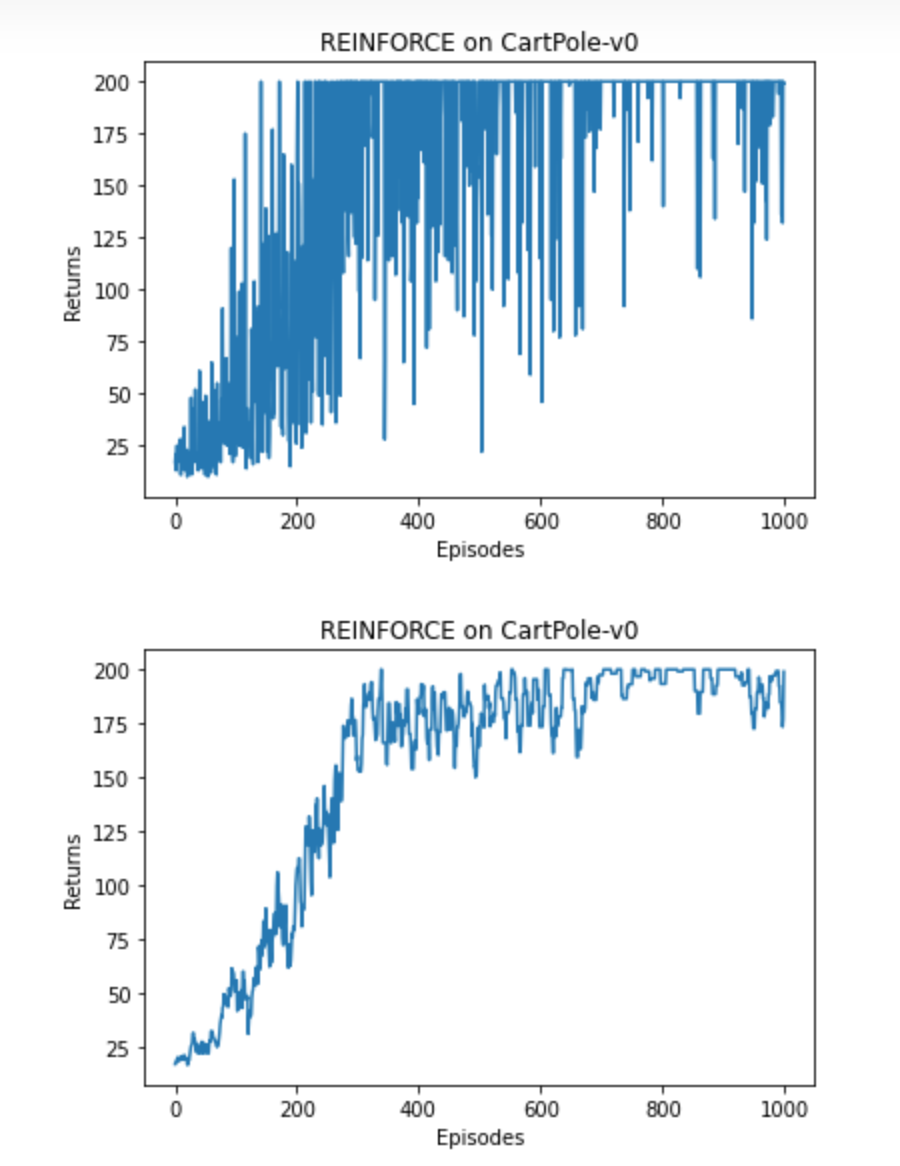

In [5]:
Image(filename='./image/re-line.png',width=600)

### 可以看到，随着收集到的轨迹越来越多，REINFORCE 算法有效地学习到了最优策略。

#### 不过，相比于前面的 DQN 算法，REINFORCE 算法使用了更多的序列：
 - 这是因为 REINFORCE 算法是一个在线策略算法，之前收集到的轨迹数据不会被再次利用。

#### 此外，REINFORCE 算法的性能也有一定程度的波动
 - 这主要是因为每条采样轨迹的回报值波动比较大，这也是 REINFORCE 算法主要的不足。

### REINFORCE 算法是策略梯度乃至强化学习的典型代表，

- 智能体根据当前策略直接和环境交互，通过采样得到的轨迹数据直接计算出策略参数的梯度，进而更新当前策略，使其向最大化策略期望回报的目标靠近。
- **这种学习方式是典型的从交互中学习**，
- 并且其优化的目标（即策略期望回报）正是最终所使用策略的性能，
- 这比基于价值的强化学习算法的优化目标（一般是时序差分误差的最小化）要更加直接。

#### REINFORCE 算法理论上是能保证局部最优的
- 它实际上是借助蒙特卡洛方法采样轨迹来估计动作价值，这种做法的一大优点是可以得到无偏的梯度。
- 但是，正是因为使用了蒙特卡洛方法，REINFORCE 算法的梯度估计的方差很大，可能会造成一定程度上的不稳定，

#### <font color="red">这也是第 10 章将介绍的 Actor-Critic 算法要解决的问题。<font>

#  策略梯度证明